In [3]:
import pandas as pd
df = pd.read_csv('data.csv')

In [5]:
df.shape


(20000, 22)

In [7]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  str    
 2   marital_status        20000 non-null  str    
 3   education_level       20000 non-null  str    
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  str    
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  str    
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  str    
 15  num_of_open_accounts  20000 no

In [9]:
#checking for  duplicates 
df.duplicated().sum()

np.int64(0)

In [10]:
#checking for target imbalance 
df["loan_paid_back"].value_counts()

loan_paid_back
1    15998
0     4002
Name: count, dtype: int64

In [11]:
df["loan_paid_back"].value_counts(normalize=True)

loan_paid_back
1    0.7999
0    0.2001
Name: proportion, dtype: float64

In [13]:
# checking for categorical columns
categorical_cols = df.select_dtypes(include=["object","string"]).columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Female    10034
Male       9536
Other       430
Name: count, dtype: int64

 marital_status
marital_status
Single      9031
Married     8974
Divorced    1428
Widowed      567
Name: count, dtype: int64

 education_level
education_level
Bachelor's     8045
High School    5919
Master's       3724
Other          1508
PhD             804
Name: count, dtype: int64

 employment_status
employment_status
Employed         13007
Self-employed     2923
Unemployed        2113
Retired           1176
Student            781
Name: count, dtype: int64

 loan_purpose
loan_purpose
Debt consolidation    7981
Other                 2550
Car                   2390
Home                  1972
Education             1675
Business              1629
Medical               1196
Vacation               607
Name: count, dtype: int64

 grade_subgrade
grade_subgrade
C3    1514
C4    1463
C2    1436
C5    1422
C1    1410
D1    1155
D3    1146
D4    1100
D2    1091
D5    1073
B2     654
B1     620
B5     604


In [15]:
# checking for numerical coumns 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,20000.0,48.027000,15.829352,21.00,35.0000,48.000,62.0000,75.000
annual_income,20000.0,43549.637766,28668.579671,6000.00,24260.7525,36585.260,54677.9175,400000.000
monthly_income,20000.0,3629.136466,2389.048326,500.00,2021.7300,3048.770,4556.4950,33333.330
debt_to_income_ratio,20000.0,0.177019,0.105059,0.01,0.0960,0.160,0.2410,0.667
credit_score,20000.0,679.256950,69.638580,373.00,632.0000,680.000,727.0000,850.000
loan_amount,20000.0,15129.300909,8605.405513,500.00,8852.6950,14946.170,20998.8675,49039.690
interest_rate,20000.0,12.400626,2.442729,3.14,10.7400,12.400,14.0025,22.510
loan_term,20000.0,43.222800,11.008380,36.00,36.0000,36.000,60.0000,60.000
installment,20000.0,455.625794,274.622125,9.43,253.9100,435.595,633.5950,1685.400
num_of_open_accounts,20000.0,5.011800,2.244529,0.00,3.0000,5.000,6.0000,15.000


In [16]:
#Check correlation between numeric columns
df.select_dtypes(include=["int64", "float64"]).corr()["loan_paid_back"].sort_values(ascending=False)

loan_paid_back          1.000000
credit_score            0.199841
age                     0.007999
public_records          0.003210
monthly_income          0.003057
annual_income           0.003057
num_of_open_accounts    0.002964
loan_amount            -0.002490
loan_term              -0.002615
total_credit_limit     -0.002985
current_balance        -0.004749
installment            -0.010068
num_of_delinquencies   -0.070896
delinquency_history    -0.084940
interest_rate          -0.110935
debt_to_income_ratio   -0.223831
Name: loan_paid_back, dtype: float64

In [ ]:
# droping monthly income beacause its derived from anual income
df = df.drop(columns=["monthly_income"])

df.shape

In [17]:
#Check categorical relationship with target
for col in categorical_cols:
    print("\n", col)
    print(df.groupby(col)["loan_paid_back"].mean().sort_values(ascending=False))


 gender
gender
Female    0.802472
Male      0.797504
Other     0.793023
Name: loan_paid_back, dtype: float64

 marital_status
marital_status
Divorced    0.805322
Married     0.800312
Single      0.799579
Widowed     0.784832
Name: loan_paid_back, dtype: float64

 education_level
education_level
PhD            0.828358
High School    0.808076
Other          0.803714
Master's       0.797798
Bachelor's     0.791299
Name: loan_paid_back, dtype: float64

 employment_status
employment_status
Retired          0.994898
Employed         0.886984
Self-employed    0.885734
Student          0.407170
Unemployed       0.181732
Name: loan_paid_back, dtype: float64

 loan_purpose
loan_purpose
Home                  0.824037
Business              0.809085
Other                 0.802745
Debt consolidation    0.799399
Car                   0.798326
Vacation              0.792422
Medical               0.782609
Education             0.777910
Name: loan_paid_back, dtype: float64

 grade_subgrade
grade_subgr

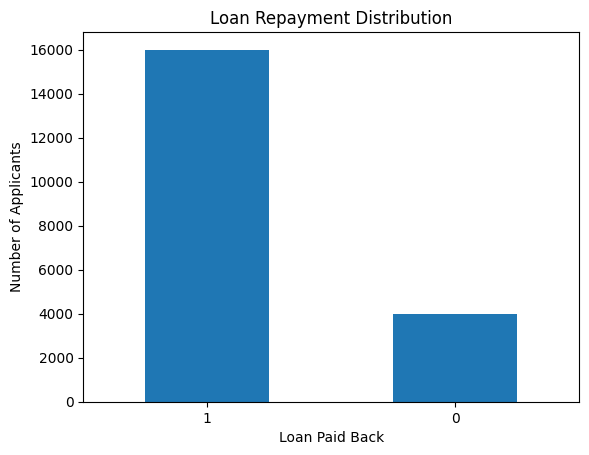

In [21]:
#A graph to target distribution paid back vs not paid back
import matplotlib.pyplot as plt

df["loan_paid_back"].value_counts().plot(kind="bar")

plt.title("Loan Repayment Distribution")
plt.xlabel("Loan Paid Back")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

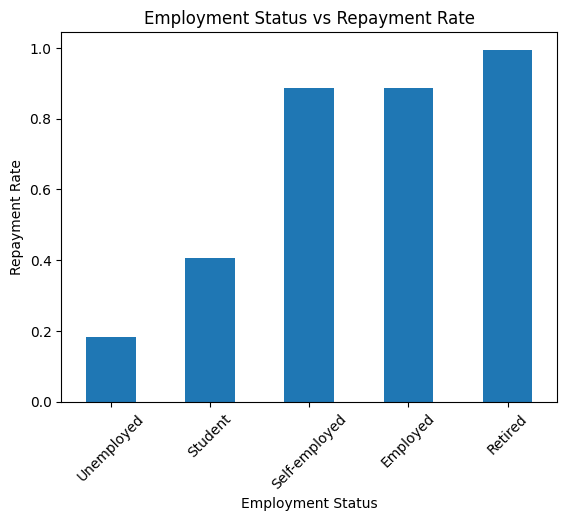

In [22]:
#Employment status vs repayment rate
import matplotlib.pyplot as plt

emp_rate = df.groupby("employment_status")["loan_paid_back"].mean().sort_values()

emp_rate.plot(kind="bar")

plt.title("Employment Status vs Repayment Rate")
plt.xlabel("Employment Status")
plt.ylabel("Repayment Rate")
plt.xticks(rotation=45)
plt.show()

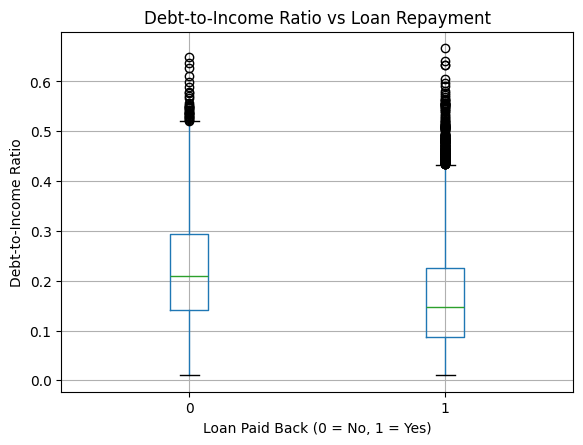

In [23]:
#Debt-to-income ratio vs loan_paid_back
import matplotlib.pyplot as plt

df.boxplot(column="debt_to_income_ratio", by="loan_paid_back")

plt.title("Debt-to-Income Ratio vs Loan Repayment")
plt.suptitle("")  # removes default title
plt.xlabel("Loan Paid Back (0 = No, 1 = Yes)")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

In [25]:
#split features 
#Split features and target
X = df.drop(columns=["loan_paid_back"])
y = df["loan_paid_back"]

print(X.shape)
print(y.shape)

(20000, 20)
(20000,)


In [29]:
categorical_cols = X.select_dtypes(include=["object","string"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
print(len(categorical_cols), "categorical")
print(len(numeric_cols), "numeric")

6 categorical
14 numeric


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(16000, 20) (4000, 20)
(16000,) (4000,)


In [32]:
# Now we encode and scale.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [34]:
#Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(16000, 69)
(4000, 69)


In [35]:
#Train XGBoost model
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_processed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [36]:
# Now evaluating the model on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.90425
Precision: 0.8964255558682803
Recall: 0.9953125
F1 Score: 0.9432844661631867
ROC-AUC: 0.8950791015624999

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.54      0.69       800
           1       0.90      1.00      0.94      3200

    accuracy                           0.90      4000
   macro avg       0.93      0.77      0.82      4000
weighted avg       0.91      0.90      0.89      4000



In [38]:
# checking the confusion matrix 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 432  368]
 [  15 3185]]


In [43]:
#368 risky borrowers were predicted as paid back
# so lets tune the classification threshold, not retrain
import numpy as np

for threshold in [0.65,0.73, 0.78,0.82,0.47]:
    y_pred_custom = (y_prob >= threshold).astype(int)
    
    print("\nThreshold:", threshold)
    print(classification_report(y_test, y_pred_custom))
    print(confusion_matrix(y_test, y_pred_custom))


Threshold: 0.65
              precision    recall  f1-score   support

           0       0.88      0.57      0.69       800
           1       0.90      0.98      0.94      3200

    accuracy                           0.90      4000
   macro avg       0.89      0.78      0.82      4000
weighted avg       0.90      0.90      0.89      4000

[[ 457  343]
 [  65 3135]]

Threshold: 0.73
              precision    recall  f1-score   support

           0       0.74      0.62      0.68       800
           1       0.91      0.95      0.93      3200

    accuracy                           0.88      4000
   macro avg       0.83      0.78      0.80      4000
weighted avg       0.88      0.88      0.88      4000

[[ 496  304]
 [ 170 3030]]

Threshold: 0.78
              precision    recall  f1-score   support

           0       0.62      0.70      0.66       800
           1       0.92      0.89      0.91      3200

    accuracy                           0.86      4000
   macro avg       0.77

In [ ]:
best_threshold = 0.73
y_pred_final = (y_prob >= best_threshold).astype(int)
#It gives a better balance for credit risk: it improves detection of risky borrowers while not rejecting too many good borrowers.

In [46]:
#Extract feature importance
import pandas as pd

# Get feature names after encoding
feature_names = preprocessor.get_feature_names_out()

# Get importance scores
importances = model.feature_importances_

# Create DataFrame
feat_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_importance.head(15)

,feature,importance
30,cat__employment_status_Unemployed,0.413511
29,cat__employment_status_Student,0.146833
27,cat__employment_status_Retired,0.039384
2,num__debt_to_income_ratio,0.038441
3,num__credit_score,0.035403
64,cat__grade_subgrade_F1,0.015648
20,cat__marital_status_Widowed,0.014251
60,cat__grade_subgrade_E2,0.011948
45,cat__grade_subgrade_B2,0.011226
59,cat__grade_subgrade_E1,0.010038


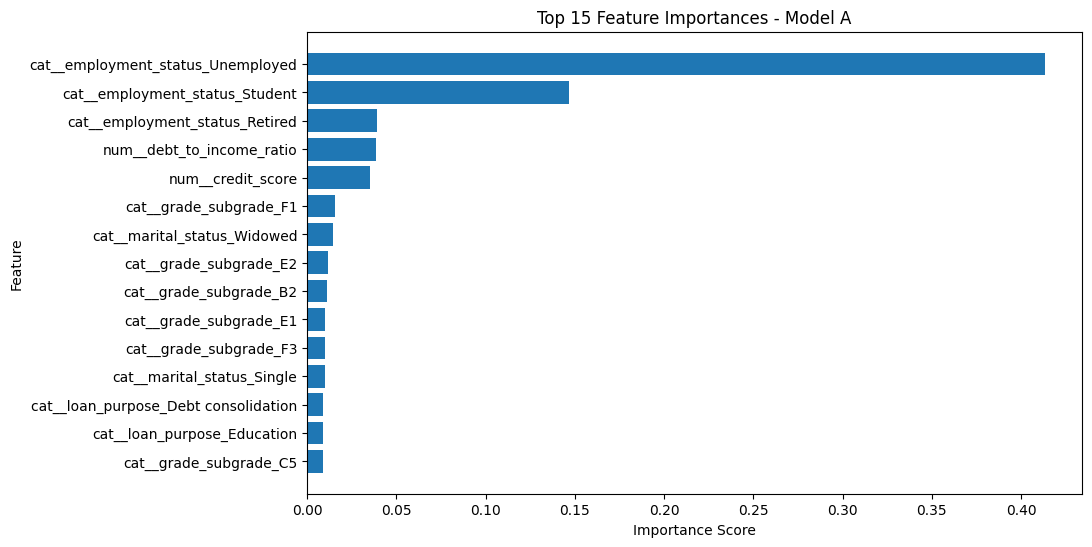

In [47]:
# create a feature importance graph.
import matplotlib.pyplot as plt

top_features = feat_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances - Model A")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [50]:
#Save model + preprocessor + threshold
import joblib

joblib.dump(model, "model_a.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

# save threshold
joblib.dump(0.73, "threshold.pkl")

['threshold.pkl']